In [1]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex06_player_heatmap_after_masking', 'pitch_segmentation_model': 'lightning_logs/version_13/checkpoints/epoch=17-step=288.ckpt', 'pitch_cover_model': 'wandb_logs/ISC-Football/pc7g8srb/checkpoints/epoch=20-step=252.ckpt', 'gaussian_heatmap_model': 'wandb_logs/ISC-Football/j333rvqe/checkpoints/epoch=31-step=896.ckpt', 'unet_with_gaussian_layer': 'wandb_logs/ISC-Football/5yaq0s0v/checkpoints/epoch=31-step=512.ckpt', 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'n_limit': 256, 'width': 960, 'height': 540, 'n_crops': 1, 'crop_width': 960, 'crop_height': 540, 'crop_export_width': 320, 'crop_export_height': 180, 'sigma': 4, 'oversampling_rate': 16.0, 'in_channels': 3}, 'spiideo_datamodule': {'batch_size': 16, 'num_workers': 10, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [72]:
%load_ext autoreload
%autoreload 2

import gc
import cv2
import json
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision.utils import make_grid
import torch.nn.functional as TorchF
import torchvision.transforms.functional as TorchvisionF

import numpy as np
import matplotlib.pyplot as plt
import random
import requests
from PIL import Image

from datamodules.spiideo.coco import COCOPredictedAnnotation
from datamodules.spiideo import SpiideoWithMetadataDataModule, SpiideoDatasetArgs
from datamodules.base_datamodule import BaseDataModuleArgs
from datamodules.spiideo.gaussian import Spiideo2DGaussianMaskDataModule, Spiideo2DGaussianMaskDatasetArgs

from dataobjects.pitch import Pitch

from models.base.unet_heatmap import UNetHeatmap
from models.player_detection.mask_then_heatmap import MaskThenHeatmap
from models.player_detection.unet_gaussian import UNetHeatmapGaussian

from pipelines.player_detection.crop_then_stitch import CropThenStitch
from pipelines.player_detection.pitch_cover import PitchCover
from pipelines.player_detection.gaussianiser import HeatmapGaussianiser

from ultralytics import YOLO
from transformers import DetrImageProcessor, DetrForObjectDetection
from transformers import SamModel, SamProcessor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
spiideo_args = SpiideoDatasetArgs(**config['spiideo_dataset'])
spiideo_data_module = SpiideoWithMetadataDataModule(
    SpiideoDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)

ds = spiideo_data_module.dataset('test')
print(f'Dataset with {len(ds)} images.')

id=0 keypoints=array([[     3074.2,      989.36,           1],
       [     3070.6,      1037.8,           1]]) keypoints_3d=array([[     2.5472,      3.3236,     0.89179,           1],
       [     2.5472,      3.3236,           0,           1]]) position_on_pitch=array([     2.5472,      3.3236]) bbox=array([3053,  950,   28,   89]) area=952.0 image_id=0 category_id=1
id=0 keypoints=array([[     768.54,      247.34,           1],
       [     767.65,      259.45,           1]]) keypoints_3d=array([[     2.5472,      3.3236,     0.89179,           1],
       [     2.5472,      3.3236,           0,           1]]) position_on_pitch=array([     2.5472,      3.3236]) bbox=array([763, 237,   7,  22]) area=952.0 image_id=0 category_id=1
Dataset with 256 images.


In [51]:
spiideo_mask_data_module = Spiideo2DGaussianMaskDataModule(
    Spiideo2DGaussianMaskDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)

mask_ds = spiideo_mask_data_module.dataset('test')

id=0 keypoints=array([[     3074.2,      989.36,           1],
       [     3070.6,      1037.8,           1]]) keypoints_3d=array([[     2.5472,      3.3236,     0.89179,           1],
       [     2.5472,      3.3236,           0,           1]]) position_on_pitch=array([     2.5472,      3.3236]) bbox=array([3053,  950,   28,   89]) area=952.0 image_id=0 category_id=1
id=0 keypoints=array([[     768.54,      247.34,           1],
       [     767.65,      259.45,           1]]) keypoints_3d=array([[     2.5472,      3.3236,     0.89179,           1],
       [     2.5472,      3.3236,           0,           1]]) position_on_pitch=array([     2.5472,      3.3236]) bbox=array([763, 237,   7,  22]) area=952.0 image_id=0 category_id=1


In [4]:
width, height = config['spiideo_dataset']['width'], config['spiideo_dataset']['height']
img, metadata, annotations, *_ = ds[0]
metadata.model_dump()

{'id': 0,
 'file_name': '000000.jpg',
 'width': 960,
 'height': 540,
 'camera_matrix': array([[   -0.50905,     0.86073,  -0.0041102,     -22.454],
        [    0.16611,     0.10292,     0.98072,   0.0009649],
        [   -0.84456,    -0.49856,     0.19537,     -39.052]]),
 'dist_poly': array([    0.03442,    -0.18697,     0.34796,    -0.17117,    -0.19061,     0.17589,    -0.10742,     0.69503, -0.00085098]),
 'undist_poly': array([ 1.3632e-11, -4.3232e-11,  5.5868e-11, -3.7653e-11,      1.3967,    -0.70406,     0.31775,      1.4397,   0.0012175])}

In [55]:
DEVICE = 'mps'
DTYPE = torch.bfloat16
# gaussian_model = UNetHeatmap \
#     .load_from_checkpoint(config['gaussian_heatmap_model'], weights_only=False) \
#     .to(DEVICE) \
#     .float() \
#     .eval()

# pitch_cover_model = UNetHeatmap \
#     .load_from_checkpoint(config['pitch_cover_model'], weights_only=False) \
#     .to(DEVICE) \
#     .float() \
#     .eval()

# pitch_cover_pipeline = PitchCover(pitch_cover_model, pad_size=25) \
#     .eval()

# full_model = UNetHeatmapGaussian(
#     masking_unet=pitch_cover_model, 
#     heatmap_unet=gaussian_model,
#     max_sigma=8) \
#         .to(DEVICE) \
#         .eval()

# Loading checkpoint error stuff
torch.hub.load('sm00thix/unet', 'unet', pretrained=False)

_full_model = UNetHeatmapGaussian \
    .load_from_checkpoint(config['unet_with_gaussian_layer']) \
    .to(device=DEVICE, dtype=DTYPE) \
    .eval()

gaussian_model = _full_model.heatmap_unet \
    .to(device=DEVICE, dtype=DTYPE) \
    .eval()

pitch_cover_model = _full_model.masking_unet \
    .to(device=DEVICE, dtype=DTYPE) \
    .eval()

full_model = UNetHeatmapGaussian(
    pitch_cover_model, gaussian_model, lmbd_gaussianiser=1, 
    max_sigma=4, top_k=10000, select_k=1000
) \
    .to(device=DEVICE, dtype=DTYPE) \
    .eval()

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main
/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues re

### Inference

In [6]:
import gc
gc.collect()
torch.mps.empty_cache()

In [7]:
# HEIGHT, WIDTH = 2160, 3840
HEIGHT, WIDTH = 540, 960

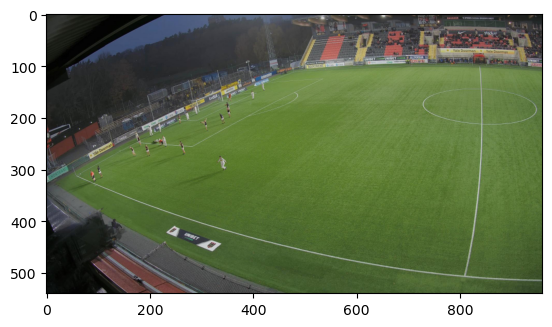

In [34]:
IMAGE_IDX = 20
img, coco_img, coco_annot, *_ = ds[IMAGE_IDX]
img = torch.tensor(img).permute((2, 0, 1)).unsqueeze(0) \
    .to(DEVICE, DTYPE)

img = TorchF.interpolate(img, size=(HEIGHT, WIDTH)).detach()

img_small = TorchF.interpolate(img, size=(540, 960)).detach()
plt.imshow(img_small[0].permute((1, 2, 0)).cpu().float())
plt.show()

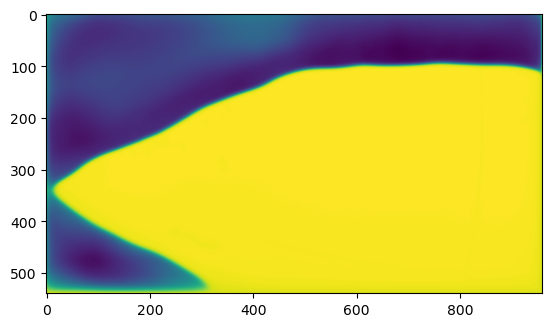

In [35]:
cover = pitch_cover_model(img_small)
cover = TorchF.interpolate(cover, size=(HEIGHT, WIDTH)).detach()
plt.imshow(cover[0].permute((1, 2, 0)).cpu().float())
plt.show()

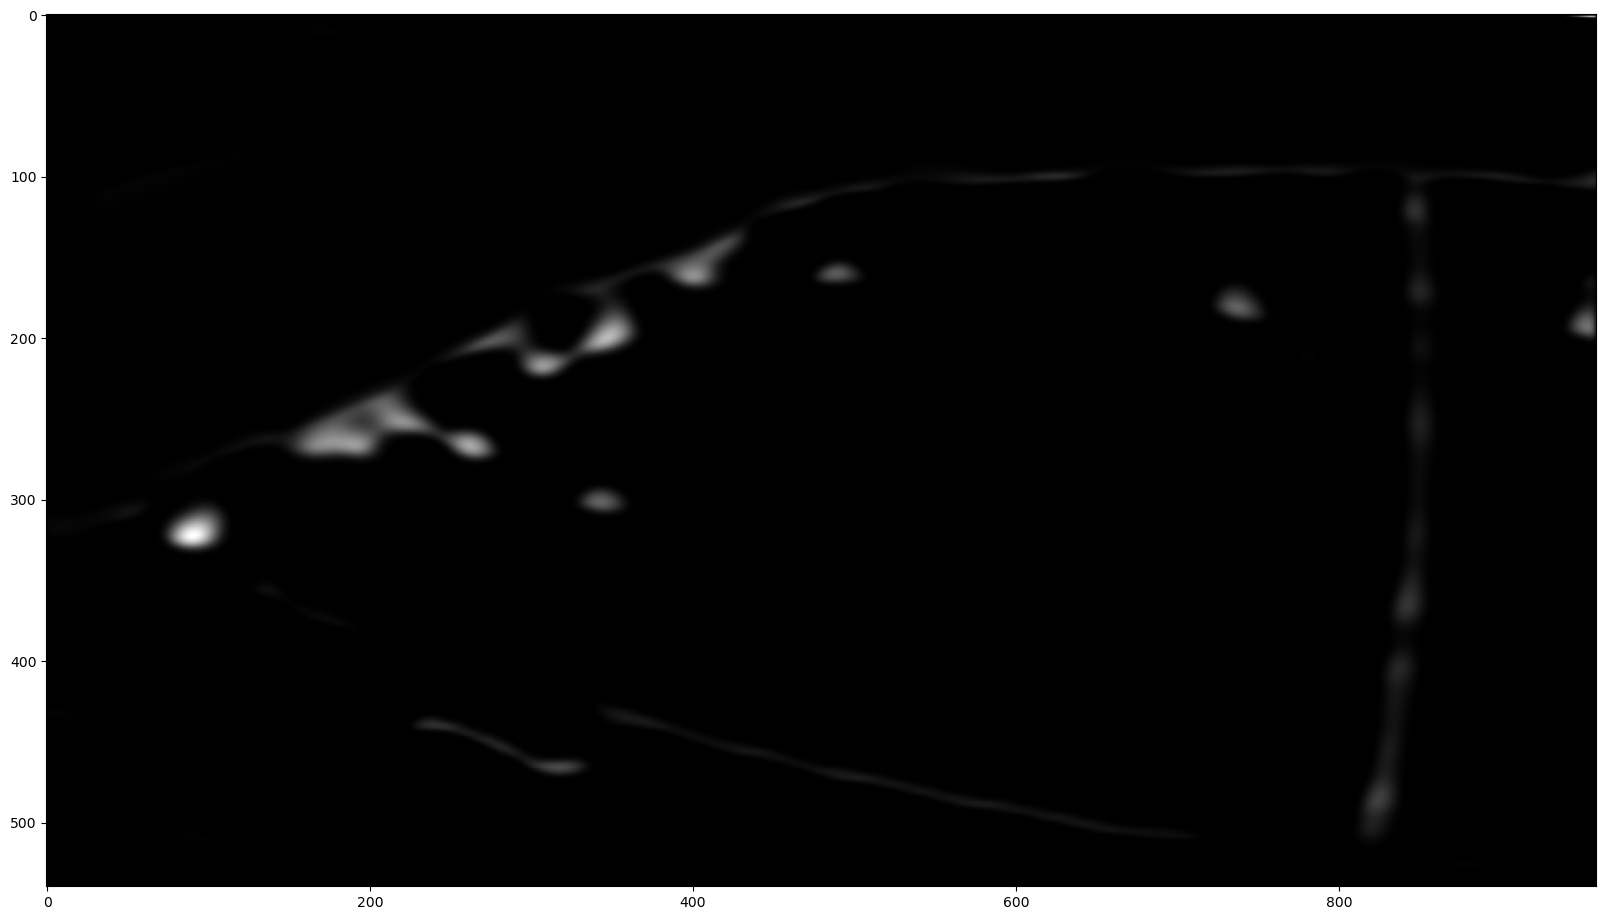

In [59]:
pre_player_mask_all = gaussian_model(img) * cover

plt.figure(figsize=(20, 15))
_img = plt.imshow(pre_player_mask_all[0][0].detach().cpu().float(), cmap='gray', vmin=0)
# plt.colorbar(_img)
plt.show()

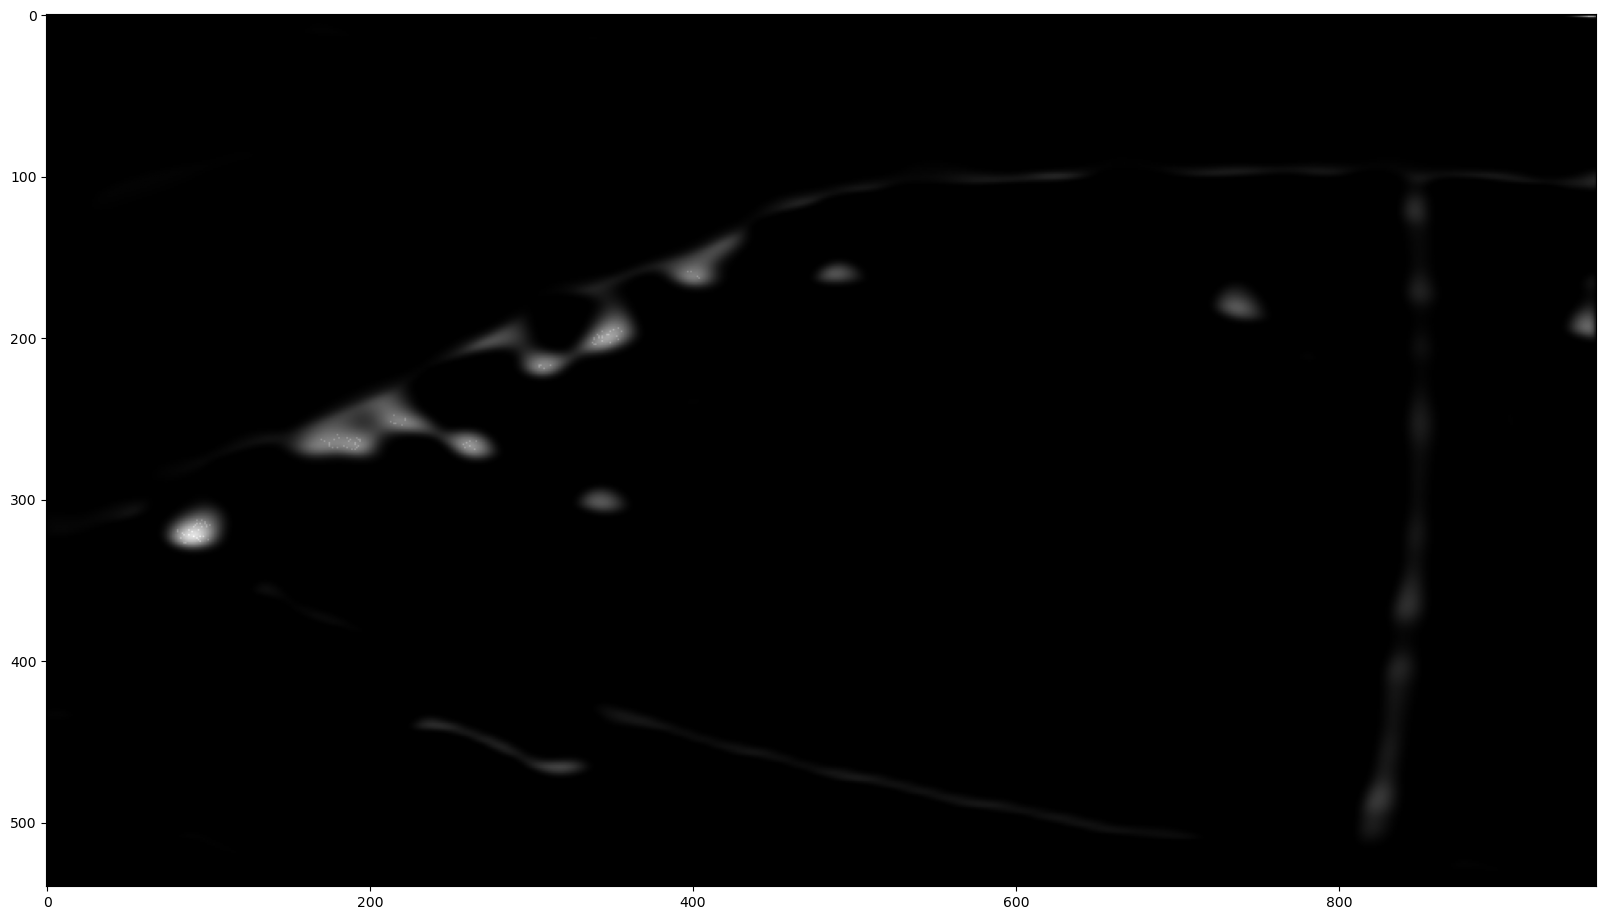

In [58]:
player_mask_all_for_training = _full_model(img) * cover

plt.figure(figsize=(20, 15))
_img = plt.imshow(player_mask_all_for_training[0][0].detach().cpu().float(), cmap='gray', vmin=0)
# plt.colorbar(_img)
plt.show()

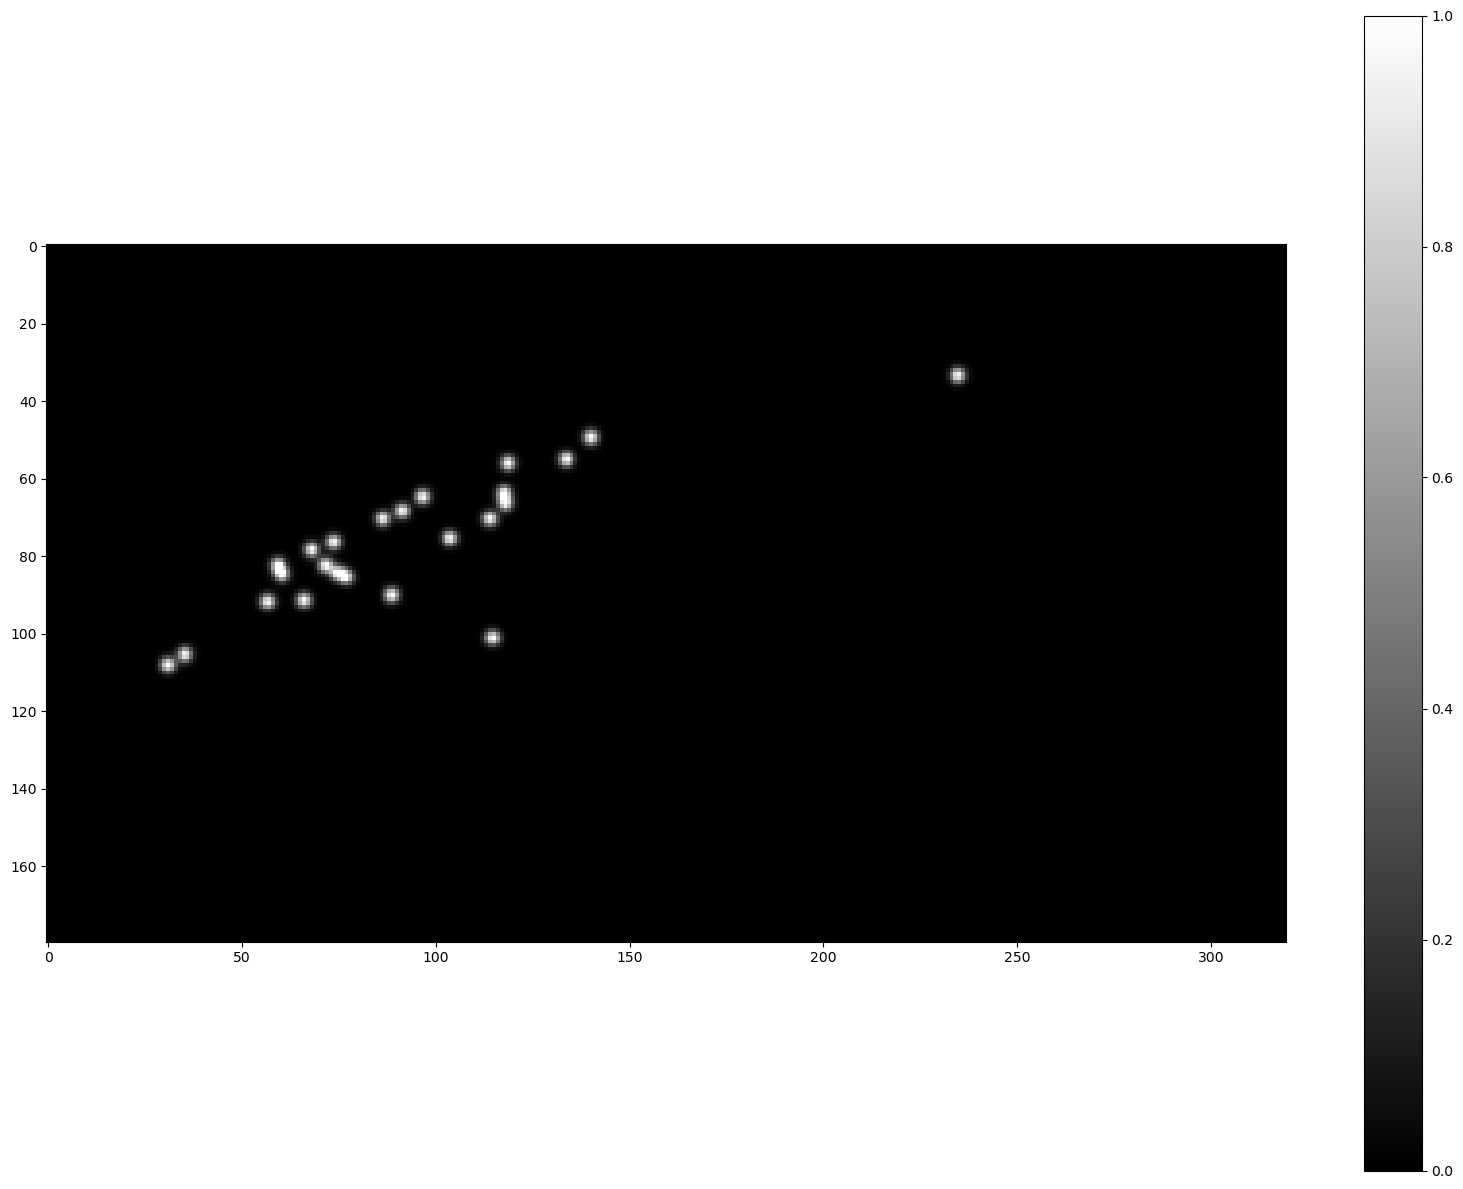

In [54]:
plt.figure(figsize=(20, 15))
_img = plt.imshow(mask_ds[IMAGE_IDX][1][0].detach().cpu().float(), cmap='gray', vmin=0)
plt.colorbar(_img)
plt.show()

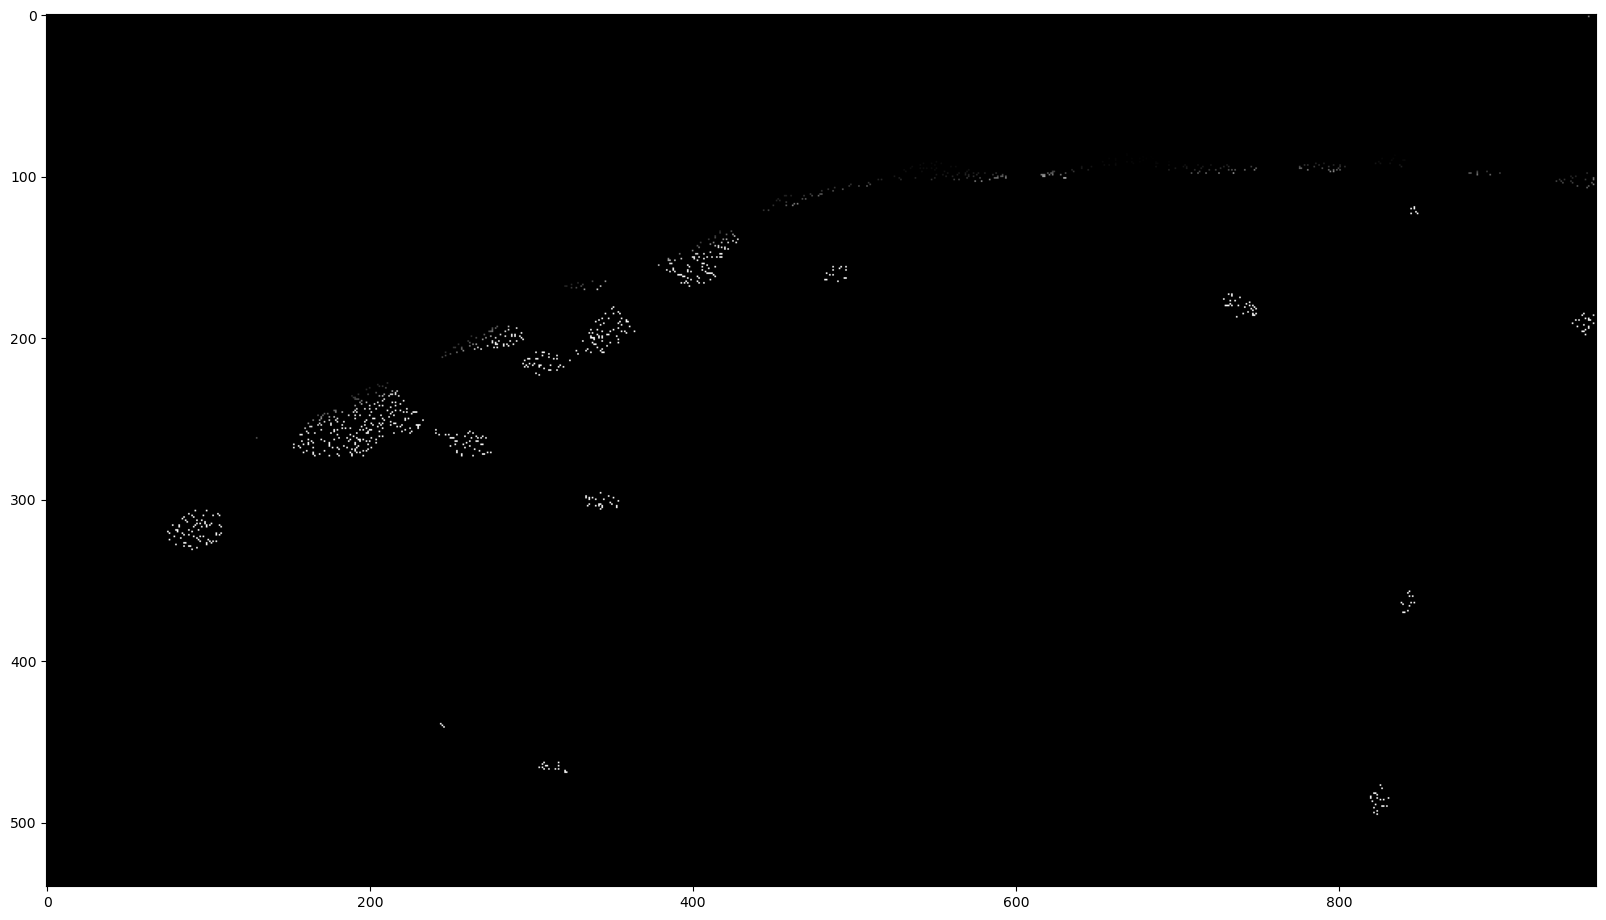

In [57]:
# player_mask_all = CropThenStitch(full_model, (HEIGHT // 4, WIDTH // 4), batch_size_per_image=1)(img) * cover
# player_mask_all = TorchF.interpolate(player_mask_all, size=(HEIGHT, WIDTH)).detach()
player_mask_all = full_model(img) * cover

plt.figure(figsize=(20, 15))
_img = plt.imshow(player_mask_all[0][0].detach().cpu().float(), cmap='gray', vmin=0)
# plt.colorbar(_img)
plt.show()

In [37]:
THRESHOLD = 0.995
clipped_mask_all = player_mask_all.detach().cpu()
clipped_mask_all = clipped_mask_all.mean(axis=1).unsqueeze(1)
clipped_mask_all[clipped_mask_all < THRESHOLD] = 0
clipped_mask_all.shape

torch.Size([1, 1, 540, 960])

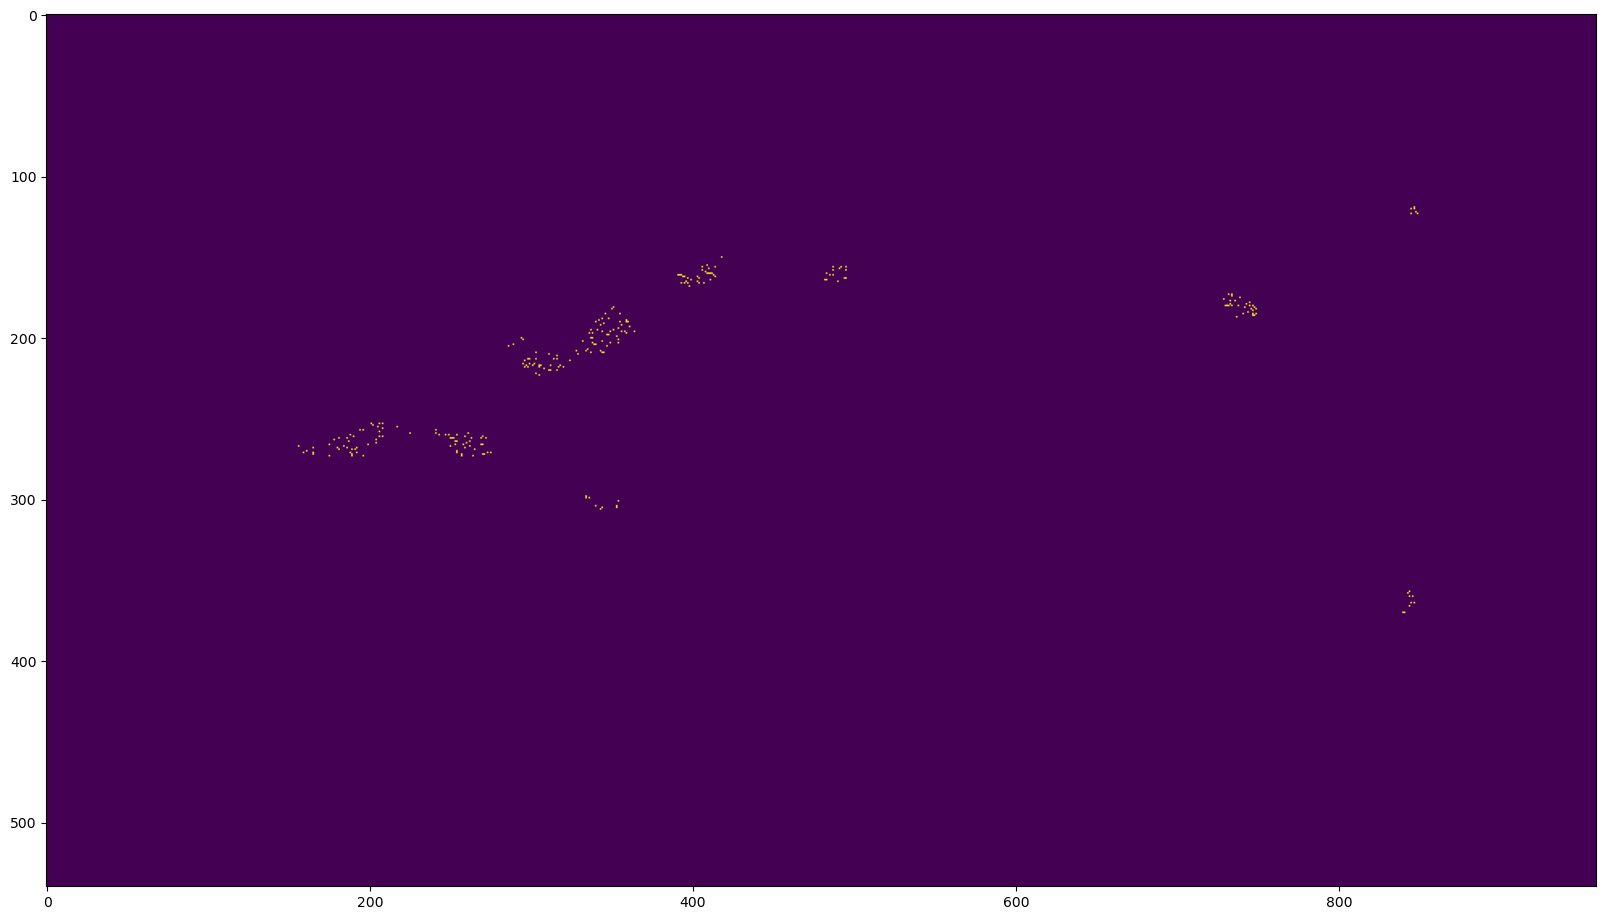

In [38]:
plt.figure(figsize=(20, 15))
plt.imshow(clipped_mask_all[0].permute((1, 2, 0)).detach().cpu().float())
plt.show()

In [39]:
%load_ext autoreload
%autoreload 2

from pipelines.player_detection.crop_then_stitch import CropThenStitch
from pipelines.player_detection.crop_then_stack import CropThenStack
from pipelines.player_detection.location_detector import LocationDetector

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
keypoints = LocationDetector(tol=0.001, num_samples=10000)(clipped_mask_all)
pts = keypoints

keypoints.shape

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


torch.Size([13, 2])

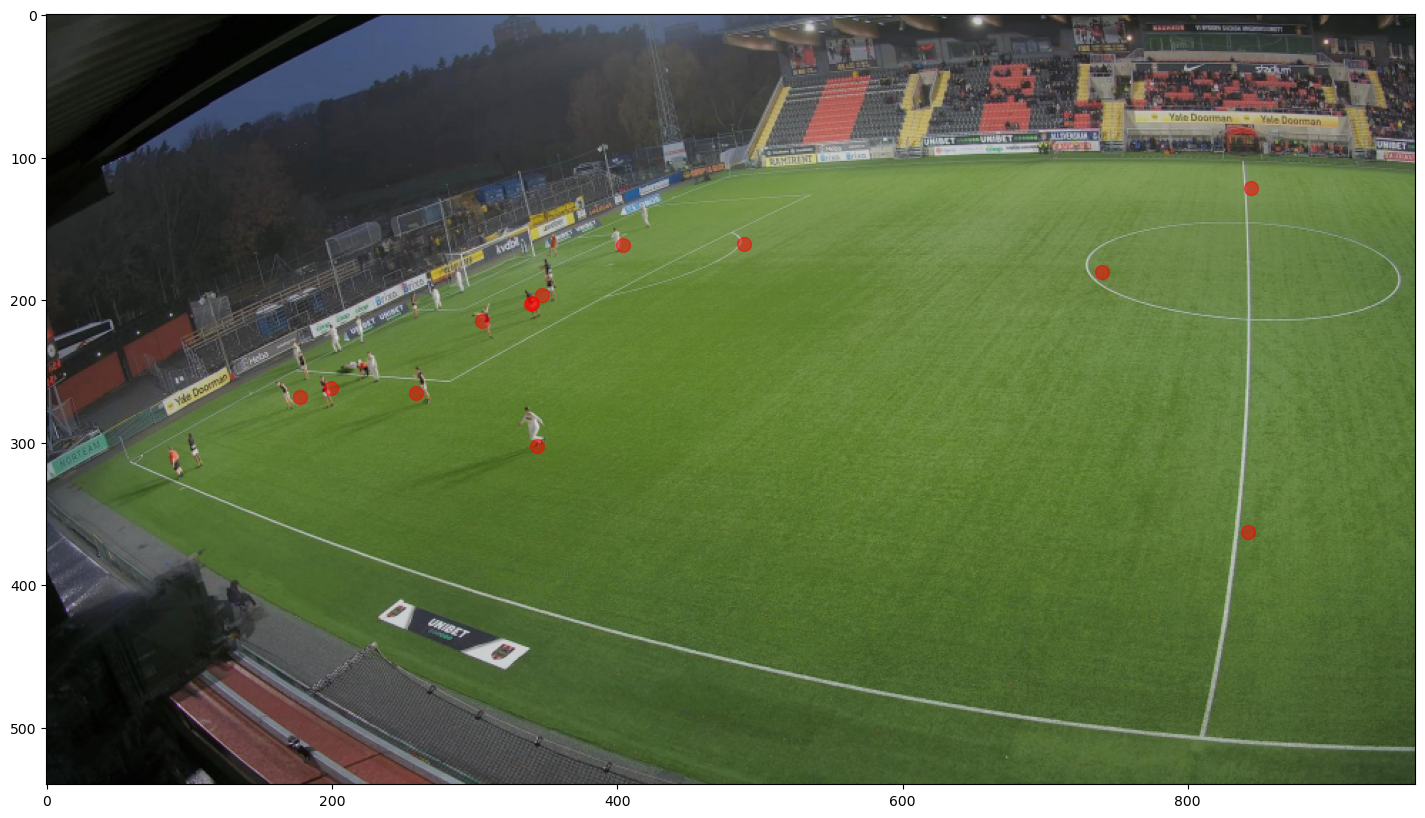

In [62]:
plt.figure(figsize=(20, 10))
plt.imshow(img[0].permute((1, 2, 0)).detach().cpu().float())
plt.scatter(pts[:, 1].detach().cpu().float(), pts[:, 0].detach().cpu().float(), c='red', s=100, alpha=0.5)
plt.show()

In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
predicted_annotations = []

coords = coco_img.coordinates_from_image_to_world(pts[:, 1].numpy(), pts[:, 0].numpy())
coords

# for idx in range(coords.shape[1]):
#     x, y = coords[:, idx]
#     annot = COCOPredictedAnnotation(
#         id=idx,
#         image_id=IMAGE_IDX,
#         category_id=1,
#         position_on_pitch=[x, y, 0]
#     )

#     predicted_annotations.append(annot.model_dump())

# with open('res.json', 'w') as f:
#     json.dump(predicted_annotations, f)

array([[      4.983,     -2.6878,     -21.597,       -25.7,     -21.864,      3.6662,     -25.009,      21.335,     -11.431,     -8.4377,     -6.7316,     -8.3411,     -23.267],
       [     42.935,      7.6446,      35.082,    -0.51741,      42.603,      31.856,       23.63,    -0.52835,      40.898,      39.611,       40.22,      39.637,      43.912]])

In [44]:
annot_world_keypoints = np.array([obj.position_on_pitch for obj in coco_annot])[:, :2].T
annot_world_keypoints

array([[    -10.908,     -15.353,     -31.552,     -21.109,     -20.267,     -24.703,     -25.183,     -5.7652,     -20.745,     -32.814,     -9.2494,     -8.1138,     -23.977,      2.9939,     -14.413,     -19.669,     -11.134,     -22.449,     -17.028,     -19.312,     -5.6734,       10.07,      33.556,
             2.4916],
       [     47.829,      48.097,      41.365,      46.379,      41.031,      42.623,      23.334,       48.94,      39.454,      41.325,      47.438,      37.982,       39.46,      41.608,      36.868,      49.339,      36.586,      33.064,      48.672,      43.641,       40.26,      44.424,      17.835,
             47.291]])

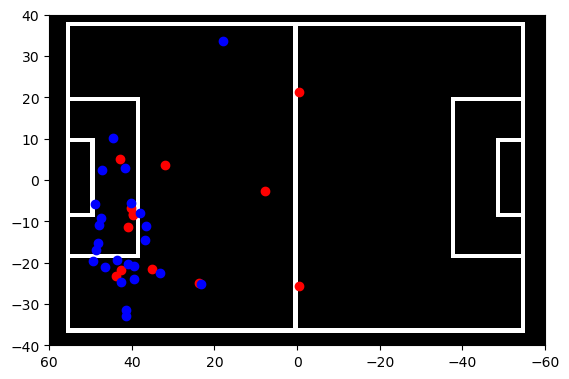

In [76]:
fig, ax = plt.subplots()
Pitch().plot(ax=ax, extra_space_scale=2, thickness=1, stroke_intensity=1)
ax.scatter(coords[1, :], coords[0, :], c='red')
ax.scatter(annot_world_keypoints[1, :], annot_world_keypoints[0, :], c='blue')

plt.xlim(60, -60)
plt.ylim(-40, 40)
plt.show()